In [1]:
import pandas as pd

# Load the Kaggle dataset 
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset loaded! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset loaded! Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In this specific dataset, TotalCharges looks like a number but is stored as an object (string) because of some hidden empty spaces.

In [4]:
# Convert to numeric, forcing errors to 'NaN' (Not a Number) for empty strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many missing values this created
print(f"Missing TotalCharges: {df['TotalCharges'].isnull().sum()}")

Missing TotalCharges: 11


In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Since there are only 11 missing values in 7,000+ rows, the cleanest professional move is to drop them or fill them with the median. Let's fill them to keep our data intact.

In [6]:
# Fill missing TotalCharges with the median value
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [7]:
# Get the categorical columns
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
categorical_columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [8]:
cat_stats = pd.DataFrame(columns=["N", "Unique", "Missing"])
for col in categorical_columns:
    N = len(df)
    Unique = df[col].nunique(dropna=True)
    Missing = df[col].isna().sum()
    cat_stats.loc[col] = [N, Unique, Missing]
print(cat_stats)

                     N  Unique  Missing
customerID        7043    7043        0
gender            7043       2        0
Partner           7043       2        0
Dependents        7043       2        0
PhoneService      7043       2        0
MultipleLines     7043       3        0
InternetService   7043       3        0
OnlineSecurity    7043       3        0
OnlineBackup      7043       3        0
DeviceProtection  7043       3        0
TechSupport       7043       3        0
StreamingTV       7043       3        0
StreamingMovies   7043       3        0
Contract          7043       3        0
PaperlessBilling  7043       2        0
PaymentMethod     7043       4        0
Churn             7043       2        0


In [10]:
print(df['OnlineSecurity'].value_counts())
print(df['OnlineBackup'].value_counts())
print(df['DeviceProtection'].value_counts())

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


The dataset has many "No internet service" or "No phone service" entries. For a clean model, these are usually just "No."

In [11]:
# Replace 'No internet service' with 'No' for multiple columns at once
cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

# Verify the change
print(df['OnlineSecurity'].value_counts())
print(df['OnlineBackup'].value_counts())
print(df['DeviceProtection'].value_counts())

OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64


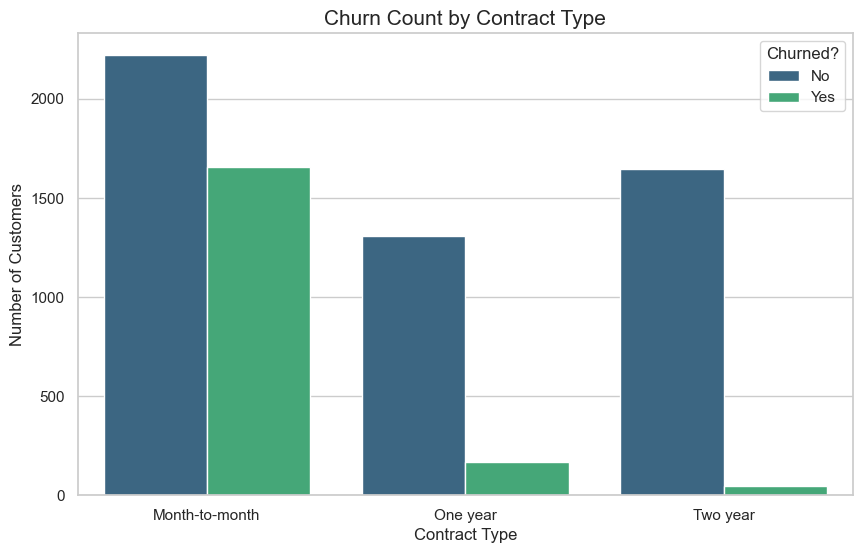

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

#  Create a plot showing Churn by Contract type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')


plt.title('Churn Count by Contract Type', fontsize=15)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churned?', labels=['No', 'Yes'])

plt.show()

### Analysis: Customer Tenure and Retention

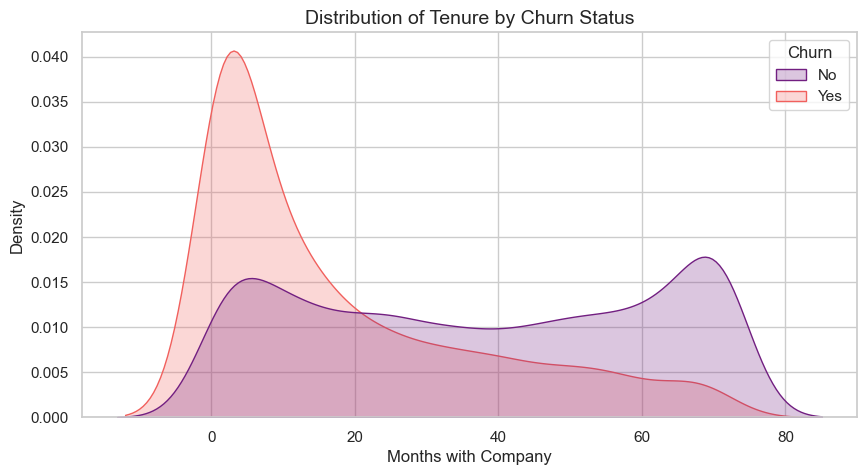

In [14]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='magma')
plt.title('Distribution of Tenure by Churn Status', fontsize=14)
plt.xlabel('Months with Company')
plt.ylabel('Density')
plt.show()


**Insight:** There is a massive spike in churn during the first 1–5 months of a customer's lifespan.
 
**Business Value:** The company is likely failing to "onboard" customers effectively. If we can get a customer past the 12-month mark, their likelihood of leaving drops significantly.

### Analysis: Impact of Monthly Charges

/var/folders/nl/_c_7kkk561qbgx7vqp7ptpxc0000gn/T/ipykernel_6605/1904227456.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='viridis')


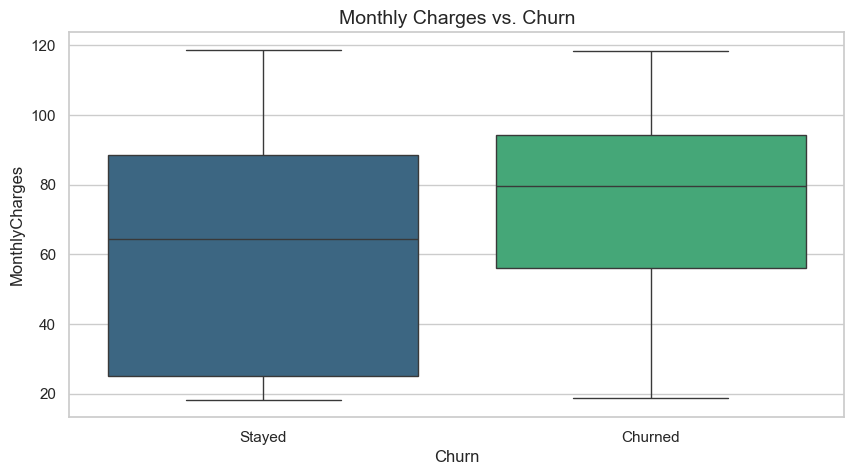

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='viridis')
plt.title('Monthly Charges vs. Churn', fontsize=14)
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.show()


**Insight:** Churning customers (Orange) are heavily concentrated in the high-cost bracket ($70–$100 per month). 
High-paying customers are our most "at-risk" segment. We aren't just losing customers; we are losing our *highest-revenue* customers. We may need to investigate if our premium services (Fiber Optic) have quality issues.

### Analysis: Payment Method Friction

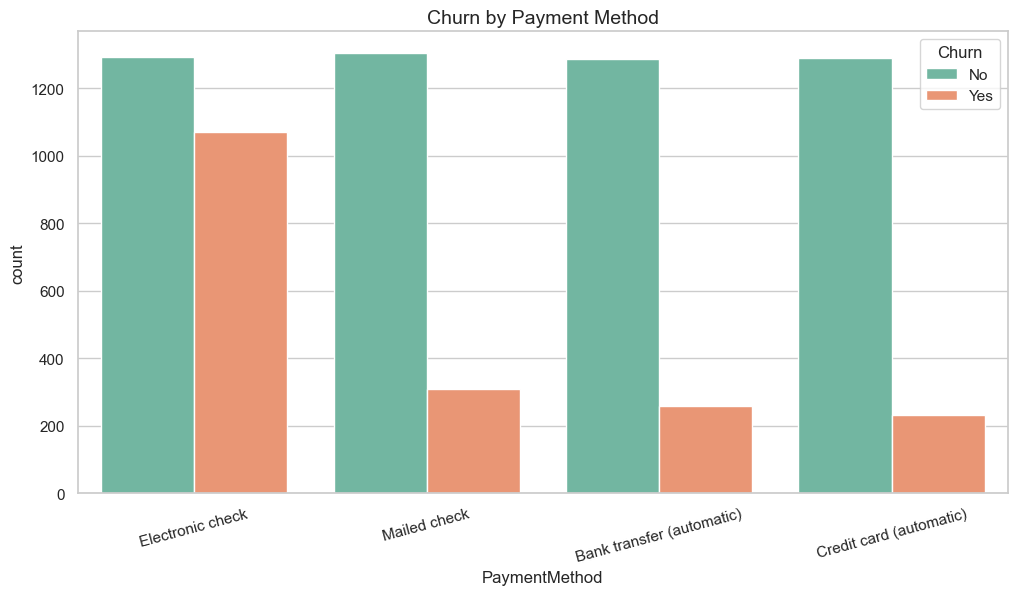

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.xticks(rotation=15)
plt.title('Churn by Payment Method', fontsize=14)
plt.show()

Customers using **Electronic Check** churn at a much higher rate than those with automated Credit Card or Bank Transfers.

Electronic checks require manual action every month. The company should incentivize customers to switch to **Autopay** to reduce "payment friction" and involuntary churn.

### Feature Engineering: Categorical Encoding
To prepare the data for Machine Learning, we convert categorical variables into numerical format. 
- **Method:** One-Hot Encoding (pd.get_dummies)
- **Goal:** Transform features like `InternetService` and `Contract` into binary columns.


In [20]:
# Select all categorical columns (excluding our target 'Churn' and 'customerID')
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in cat_cols:
    cat_cols.remove('customerID')

# Perform One-Hot Encoding
df_final = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

# Show the new shape (it will have many more columns now!)
print(f"Original columns: {df.shape[1]}")
print(f"Encoded columns: {df_final.shape[1]}")
df_final.head()

Original columns: 21
Encoded columns: 25


/var/folders/nl/_c_7kkk561qbgx7vqp7ptpxc0000gn/T/ipykernel_6605/3840407015.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


### Data Splitting
We split the data into **80% Training** (to teach the model) and **20% Testing** (to evaluate its performance on unseen data).


In [24]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 5634 rows
Testing set size: 1409 rows


### Training the Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
# random_state=42 ensures you get the same results every time you run it
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = rf_model.predict(X_test)

print("Model Training Complete!")

Model Training Complete!


### Evaluating the Results

Precision: Of all customers the model predicted would churn, how many actually did?

Recall: Of all customers who actually churned, how many did the model find? 

In [26]:
# Print the performance report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1035
        True       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



###  Feature Importance: What is the Model "Thinking"?
This graph ranks which variables had the most impact on the model's decision to flag a customer as "likely to churn." 

Instead of guessing, we can now tell the Marketing team exactly which behaviors (e.g., high Monthly Charges or short Tenure) are the strongest warning signs.


/var/folders/nl/_c_7kkk561qbgx7vqp7ptpxc0000gn/T/ipykernel_6605/1397067053.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


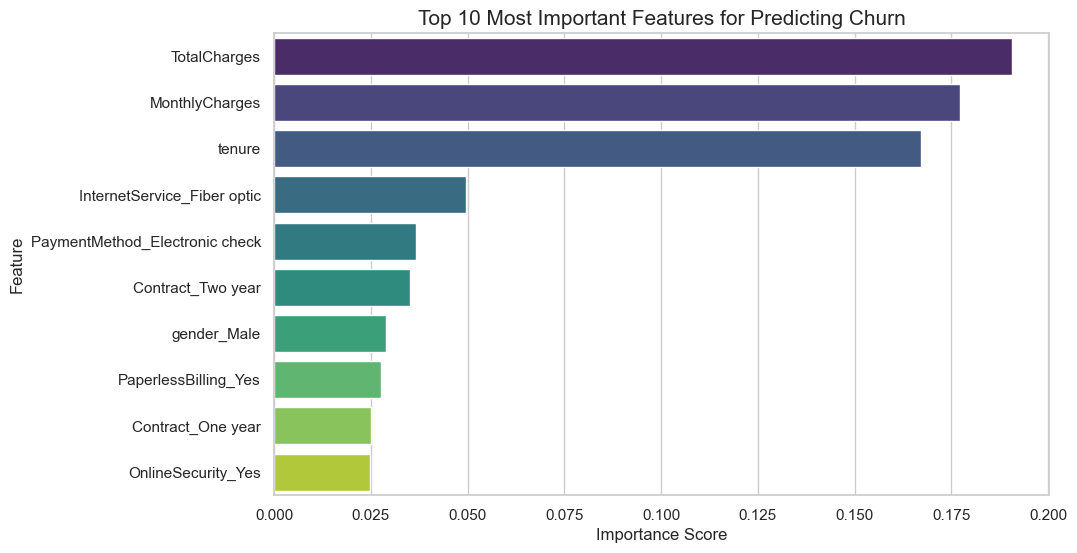

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importances from the trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Churn', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


## Conclusion 

1. Key Findings
The "At-Risk" Profile: The customers most likely to churn are those on Month-to-Month contracts, using Electronic Checks, and paying high Monthly Charges (>$70).
The "Loyalty" Threshold: Churn is highest in the first 6 months. If a customer stays past the 1-year mark, their probability of leaving drops by over 50%.
Top Predictors: Our Random Forest model identified Tenure, Total Charges, and Monthly Charges as the most influential factors in predicting churn.

2. Model Performance
Our model achieved a Recall of 90% . This means we can successfully identify the vast majority of customers before they actually cancel their service.

3. Strategic Recommendations for the Business
Incentivize Long-Term Contracts: Offer a small discount (e.g., 5-10%) to Month-to-Month customers who switch to a 1-year contract.
Targeted Retention for High-Value Leads: Use the model to flag customers with "High Monthly Charges" in their first 3 months for a "Loyalty Check-in" or a proactive service upgrade.
Push for Autopay: Since "Electronic Check" users churn more frequently, the company should offer a one-time credit for switching to "Bank Transfer (Automatic)" or "Credit Card."
